# Functions and Definitions

## Imports

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.spatial.distance import cdist
from scipy.spatial.distance import euclidean
from scipy.stats import entropy
from scipy.integrate import solve_ivp
#from sklearn.decomposition import PCA
from sklearn.cluster import SpectralClustering
import itertools
from itertools import combinations
from itertools import product
import pickle

## 1. Base Pipeline Functions

Translate (n,d) time series into recurrence matrix

In [ ]:
def recurrence_matrix(X, epsilon=0.1, norm='euclidean', normalize=False):

    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    if normalize:
        X_min, X_max = X.min(axis=0), X.max(axis=0)
        X = (X - X_min) / (X_max - X_min + 1e-12)

    # Compute pairwise distances
    D = cdist(X, X, metric=norm)

    # Apply threshold
    R = (D <= epsilon).astype(int)

    return R, D

Generate microstate probability histogram

In [ ]:
def microstate_probabilities(R, m=2):
    N = R.shape[0]
    n_states = 2 ** (m * m)
    counts = np.zeros(n_states, dtype=int)

    # Looping over all top-left corners of m×m blocks
    for i in range(N - m + 1):
        for j in range(i + 1, N - m + 1):  # only above LOI (i < j)
            block = R[i:i+m, j:j+m]
            # Flattening to binary string, then to integer
            idx = int(''.join(block.astype(int).flatten().astype(str)), 2)
            counts[idx] += 1

    total = counts.sum()
    probs = counts / total if total > 0 else counts
    return probs

Generate and codify microstate symmetry classes

In [ ]:
def generate_microstate_classes(N=2):
    """
    Returns:

    index_to_class : np.ndarray of shape (2**(N**2),)
        For each microstate index (0 .. 2^(N^2)-1),
        gives its class ID.
    classes : list[list[int]]
        Each element is a list of microstate indices belonging
        to one equivalence class.
    """

    total = 2 ** (N * N)
    index_to_class = -np.ones(total, dtype=int)
    classes = []
    class_id = 0

    # Precompute all row and column permutations
    row_perms = list(itertools.permutations(range(N)))
    col_perms = list(itertools.permutations(range(N)))

    for idx in range(total):
        if index_to_class[idx] != -1:
            continue  # already assigned

        # reconstruct binary matrix from index
        bits = np.array(list(np.binary_repr(idx, width=N * N)), dtype=int)
        mat = bits.reshape((N, N))

        # generate all equivalent matrices under the group actions
        equivalents = set()
        for rp in row_perms:
            for cp in col_perms:
                permuted = mat[np.ix_(rp, cp)]
                equivalents.add(int(''.join(permuted.flatten().astype(str)), 2))
                # add its transpose
                transposed = permuted.T
                equivalents.add(int(''.join(transposed.flatten().astype(str)), 2))
        equivalents = sorted(equivalents)

        # assign class ID
        for e in equivalents:
            index_to_class[e] = class_id
        classes.append(equivalents)
        class_id += 1

    return index_to_class, classes

Plot microstate symmetry classes

In [ ]:
def plot_microstate_classes(classes, N_micro, show_ids=True):

    n_classes = len(classes)
    max_len = max(len(c) for c in classes)

    fig, axes = plt.subplots(
        n_classes, max_len,
        figsize=(1.4 * max_len, 1.4 * n_classes)
    )

    if n_classes == 1:
        axes = np.array([axes])

    for a, micro_indices in enumerate(classes):
        for j in range(max_len):
            ax = axes[a, j]

            if j < len(micro_indices):
                idx = micro_indices[j]

                bits = np.array(
                    list(np.binary_repr(idx, width=N_micro * N_micro)),
                    dtype=int
                )
                mat = bits.reshape((N_micro, N_micro))

                ax.imshow(mat, cmap='gray_r', vmin=0, vmax=1)

                if show_ids:
                    ax.set_title(f'{idx}', fontsize=9, pad=4)
            else:
                ax.axis('off')

            ax.set_xticks([])
            ax.set_yticks([])

        # Class label on the left
        axes[a, 0].set_ylabel(f'Class {a}',
                              rotation=0,
                              labelpad=40,
                              va='center',
                              fontsize=11)

    plt.suptitle('Symmetry Classes of Recurrence Microstates',
                 fontsize=15, y=0.98)
    plt.tight_layout()
    plt.show()


## 2. Epsilon Sweep Pipeline

Probability histogram (for each iterated epsilon), other features can be added

In [ ]:
def epsilon_sweep_features(X, eps_grid, N_micro=4, norm='euclidean',
                           normalize=False, index_to_class=None):
    """
    For each epsilon in eps_grid:
      - compute recurrence matrix R
      - calculate histogram probs
      - return dictionary with per-eps results
    """

    per_eps = []
    for eps in eps_grid:
        R, _ = recurrence_matrix(X, epsilon=eps, norm=norm, normalize=normalize)
        probs = microstate_probabilities(R, m=N_micro)      # length 2^(N^2)
        per_eps.append(dict(eps=eps, probs=probs))
    return per_eps

Plot degeneracy lifting diagram

In [ ]:
def lighten_color(color, amount):
    """
    Lightens the given color
    amount = 0 -> original color
    amount = 1 -> white
    """
    c = np.array(mcolors.to_rgb(color))
    return tuple(c + (1 - c) * amount)


def generate_distinct_colors(n_classes, saturation=0.75, value=0.85):
    """
    Generate n visually distinct colors
    """
    hues = np.linspace(0, 1, n_classes, endpoint=False)
    colors = [mcolors.hsv_to_rgb((h, saturation, value)) for h in hues]
    return colors


def plot_class_microstate_probabilities(title, per_eps, classes, class_ids=None,
                                        alpha=0.9, lw=1.4):

    epsilons = np.array([d['eps'] for d in per_eps])
    probs_eps = np.array([d['probs'] for d in per_eps])  # (n_eps, n_micro)

    n_classes = len(classes)
    if class_ids is None:
        class_ids = list(range(n_classes))

    # Generate maximally distinct base colors
    base_colors = generate_distinct_colors(len(class_ids))

    plt.figure(figsize=(13, 6))
    legend_handles = []

    for c_idx, a in enumerate(class_ids):
        base_color = base_colors[c_idx]
        micro_indices = classes[a]
        n_micro = len(micro_indices)

        # Tone variation (lighter → darker)
        tones = np.linspace(0.6, 0.0, n_micro)

        for k, mi in enumerate(micro_indices):
            color = lighten_color(base_color, tones[k])
            p_curve = probs_eps[:, mi]

            plt.plot(epsilons, p_curve,
                     color=color, alpha=alpha, lw=lw)

            legend_handles.append(
                plt.Line2D(
                    [0], [0],
                    color=color, lw=3,
                    label=f'Class {a} – Microstate {mi}'
                )
            )

    plt.xlabel(r'$\varepsilon$', fontsize=12)
    plt.ylabel(r'$p(M)$', fontsize=12)
    plt.title(f'Degeneracy Breaking of Microstates - {title}\n'
              '(Distinct Hue = Original Symmetry Class, Tone = Microstate)',
              fontsize=14)
    plt.grid(alpha=0.3)

    plt.legend(handles=legend_handles,
               bbox_to_anchor=(1.02, 1),
               loc='upper left',
               borderaxespad=0.,
               fontsize=9)

    plt.tight_layout()
    plt.show()

Detect subclasses

In [ ]:
def detect_subclasses(per_eps, tol=1e-3):
    """
    Detect dynamical subclasses across ALL microstates,
    regardless of orignal symmetry class.
    """

    # Stack probability curves
    probs_eps = np.array([d['probs'] for d in per_eps])  # (n_eps, n_micro)

    n_micro = probs_eps.shape[1]
    used = set()
    subclasses = []

    for i in range(n_micro):
        if i in used:
            continue

        current_subclass = [i]
        used.add(i)

        p_i = probs_eps[:, i]

        for j in range(i + 1, n_micro):
            if j in used:
                continue

            p_j = probs_eps[:, j]

            dist = np.mean(np.abs(p_i - p_j))

            if dist < tol:
                current_subclass.append(j)
                used.add(j)

        subclasses.append(current_subclass)

    return subclasses

## 3. Markov Pipeline

Generate Symbolic field from RP

In [ ]:
def microstate_symbolic_field(R, m=2):
    """
    Returns symbolic microstate field S(i,j)
    with integer labels from 0 to 15.
    """
    n = R.shape[0]
    size = n - m + 1

    S = np.zeros((size, size), dtype=int)

    for i in range(size):
        for j in range(size):
            block = R[i:i+m, j:j+m]

            # Convert 2x2 binary block to integer ID (row-major)
            bits = block.flatten()
            idx = 0
            for bit in bits:
                idx = (idx << 1) | int(bit)

            S[i, j] = idx

    return S

Build Transition Matrix

In [ ]:
def build_transition_matrix(S, n_states=16):
    """
    Build 16x16 microstate transition matrix
    using diagonal shift (i,j) -> (i+1,j+1).
    """
    counts = np.zeros((n_states, n_states))
    rows, cols = S.shape

    for i in range(rows - 1):
        for j in range(cols - 1):
            a = S[i, j]
            b = S[i+1, j+1]
            counts[a, b] += 1

    # Normalize rows to obtain probabilities
    row_sums = counts.sum(axis=1, keepdims=True)
    P = np.divide(counts, row_sums, where=row_sums != 0)

    return P

Plot transition matrix

In [ ]:
def plot_transition_matrix(P, title="Transition Matrix"):
    plt.figure(figsize=(6,5))
    plt.imshow(P, cmap='viridis')
    plt.colorbar()
    plt.title(title)
    plt.xlabel("Next state")
    plt.ylabel("Current state")
    plt.show()

Impose row-based degeneracy splitting

In [ ]:
def row_divergence_within_classes(P, symmetry_classes):
    """
    Measure average Euclidean row divergence inside each symmetry class.
    """
    divergence = {}

    for class_id, states in symmetry_classes.items():
        dists = []
        for a, b in combinations(states, 2):
            d = euclidean(P[a], P[b])
            dists.append(d)

        divergence[class_id] = np.mean(dists) if dists else 0.0

    return divergence

Index global degeneracy

In [ ]:
def global_degeneracy_index(P, symmetry_classes):
    div = row_divergence_within_classes(P, symmetry_classes)
    return np.mean(list(div.values()))

Detect subclass formation from transition matrix action

In [ ]:
def detect_dynamical_subclasses(P, n_clusters=4):
    """
    Spectral clustering on transition matrix rows.
    """
    clustering = SpectralClustering(
        n_clusters=n_clusters,
        affinity='nearest_neighbors',
        assign_labels='kmeans',
        random_state=0
    )

    labels = clustering.fit_predict(P)
    return labels

transtion matrix spectral signature

In [ ]:
def transition_spectrum(P):
    eigvals = np.linalg.eigvals(P)
    eigvals = np.sort(np.abs(eigvals))[::-1]
    return eigvals

## 4. Correlation Tensor Pipeline

Calculate tensor from histogram

In [ ]:
def tensor_via_histogram(R, m=2):
    probs = microstate_probabilities(R, m)
    return probs.reshape((2,2,2,2))

Calculate tensor from definition

In [ ]:
def tensor_via_definition(R, m=2):
    N = R.shape[0]
    blocks = []

    for i in range(N - m + 1):
        for j in range(i + 1, N - m + 1):
            block = R[i:i+m, j:j+m]
            blocks.append(block.flatten())

    blocks = np.array(blocks)
    n_blocks = len(blocks)

    tensor = np.zeros((2,2,2,2))

    for a in product([0,1], repeat=4):
        a = np.array(a)

        term = np.ones(n_blocks)
        for k in range(4):
            term *= blocks[:,k]**a[k] * (1 - blocks[:,k])**(1 - a[k])

        tensor[tuple(a)] = np.mean(term)

    return tensor

Test consistency

In [ ]:
def consistency_test_sweep(x, eps_values, recurrence_matrix):

    max_diffs = []

    for eps in eps_values:
        R, _ = recurrence_matrix(x, eps)

        T_hist = tensor_via_histogram(R)
        T_def  = tensor_via_definition(R)

        max_diff = np.max(np.abs(T_hist - T_def))
        max_diffs.append(max_diff)

        print(f"eps={eps:.5f}  max_diff={max_diff:.3e}")

    return np.array(max_diffs)

## Aux Functions

In [ ]:
#function to save generated per_eps files
def save_per_eps(per_eps, filename):
    with open(filename, 'wb') as f:
        pickle.dump(per_eps, f, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
#function to load saved per_eps files
def load_per_eps(filename):
    with open(filename, 'rb') as f:
        per_eps = pickle.load(f)
    return per_eps

In [ ]:
# Micrrostate ID -> Matrix
def microstate_id_to_matrix(idx, N):
    bits = np.array(
        list(np.binary_repr(idx, width=N*N)),
        dtype=int
    )
    return bits.reshape((N, N))

# Degeneracy Breaking on Several Systems (N=2 Microstates)

In [ ]:
#preparing microstate classes
N_micro = 2
index_to_class, classes = generate_microstate_classes(N=N_micro)

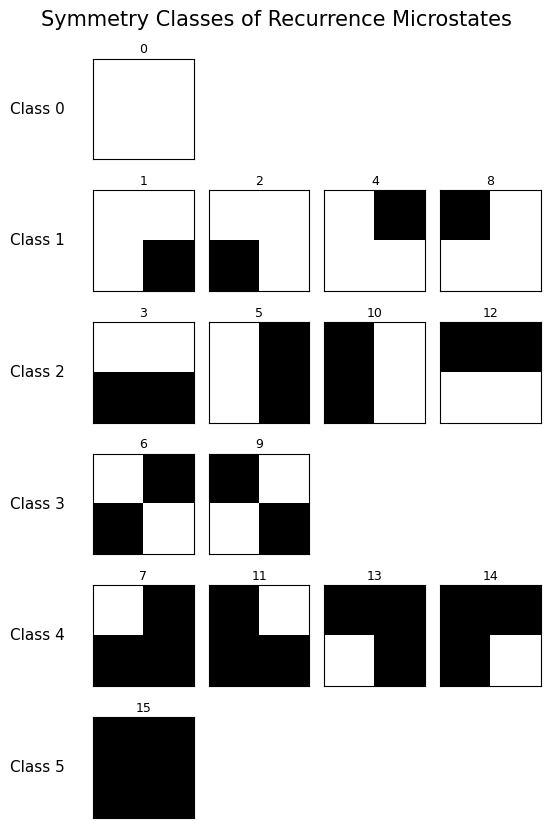

In [ ]:
plot_microstate_classes(classes, N_micro)

## Testing on White Noise

### Simulating and Saving Data

In [ ]:
#generating white noise
np.random.seed(15)
N = 2000
X_white = np.random.rand(N)

In [ ]:
#preparing epsilon sweep
eps_grid = np.linspace(0.01, 0.5, 40)

per_eps_white = epsilon_sweep_features(
    X_white,
    eps_grid=eps_grid,
    N_micro=N_micro,
    norm='euclidean',
    normalize=True,
    index_to_class=index_to_class
)

In [ ]:
save_per_eps(per_eps_white, 'per_eps_white.pkl')

meta = {
    'N_micro': N_micro,
    'eps_grid': eps_grid,
    'system': 'white_noise',
    'norm': 'euclidean',
    'normalized': True
}

with open('meta_white.pkl', 'wb') as f:
    pickle.dump(meta, f)

### Data Loading and Display

In [ ]:
per_eps_white = load_per_eps('per_eps_white.pkl')

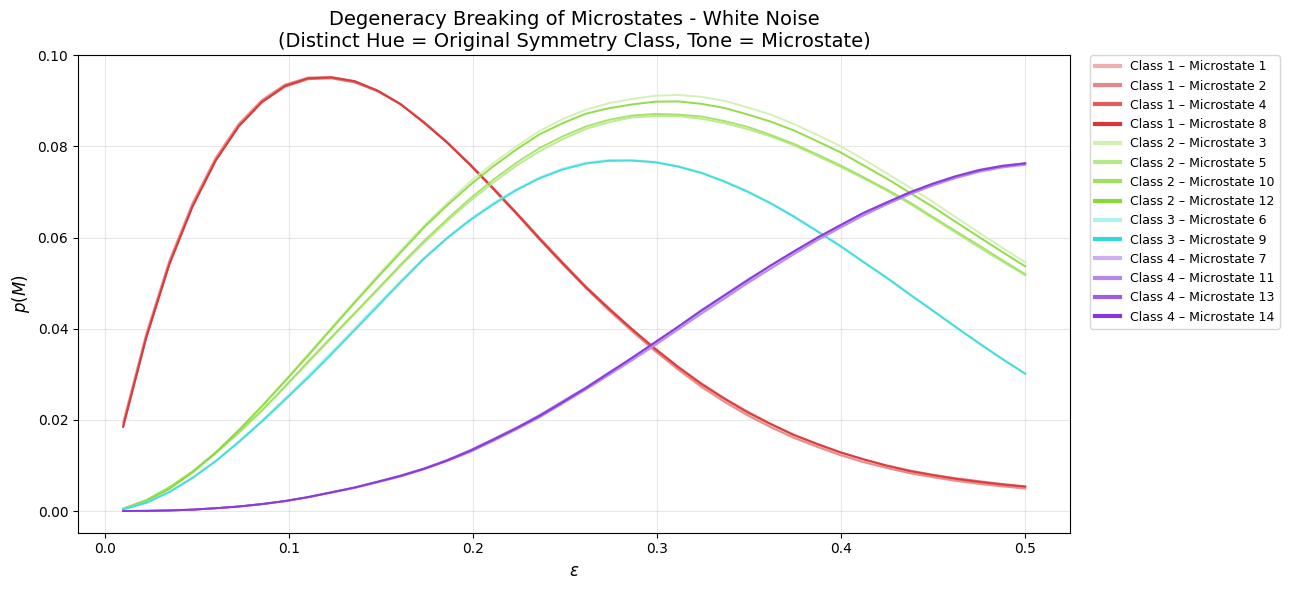

In [ ]:
plot_class_microstate_probabilities(
    'White Noise',
    per_eps_white,
    classes,
    class_ids=[1, 2, 3, 4]
)

In [ ]:
detect_subclasses(per_eps_white, 3.5e-3) # ideal tolerance usually conforms to 3% of displayed p(M) range

[[0], [1, 2, 4, 8], [3, 5, 10, 12], [6, 9], [7, 11, 13, 14], [15]]

## Testing on Colored AR(1) Noise

### Simulating and Saving Data

In [ ]:
np.random.seed(15)

N = 2000
alpha = 0.9   # correlation strength (|alpha| < 1)

# white noise
eps = np.random.randn(N)

# colored noise
x = np.zeros(N)
for t in range(1, N):
    x[t] = alpha * x[t-1] + eps[t]

# normalizing
X_colored_AR1 = (x - np.mean(x)) / np.std(x)

In [ ]:
#preparing epsilon sweep
eps_grid = np.linspace(0.01, 0.5, 40)

per_eps_colored_AR1 = epsilon_sweep_features(
    X_colored_AR1,
    eps_grid=eps_grid,
    N_micro=N_micro,
    norm='euclidean',
    normalize=True,
    index_to_class=index_to_class
)

In [ ]:
save_per_eps(per_eps_colored_AR1, 'per_eps_colored_AR1.pkl')

meta = {
    'N_micro': N_micro,
    'eps_grid': eps_grid,
    'system': 'colored_AR1',
    'norm': 'euclidean',
    'normalized': True
}

with open('meta_colored_AR1.pkl', 'wb') as f:
    pickle.dump(meta, f)

### Data Loading and Display

In [ ]:
per_eps_colored_AR1 = load_per_eps('per_eps_colored_AR1.pkl')

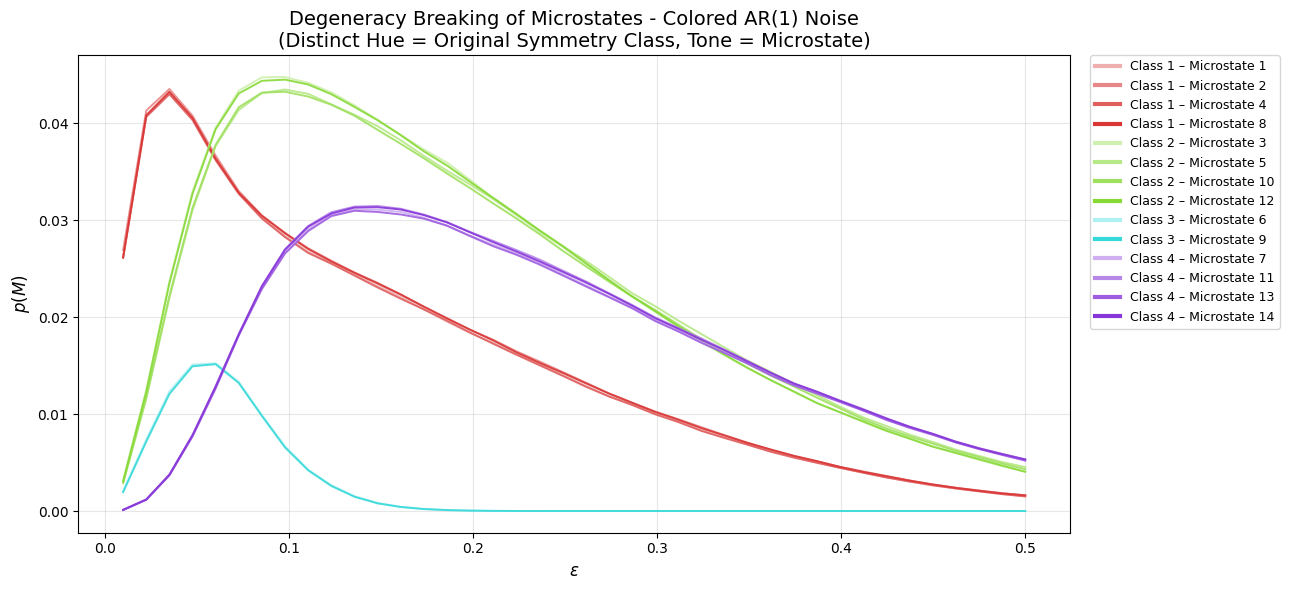

In [ ]:
plot_class_microstate_probabilities(
    'Colored AR(1) Noise',
    per_eps_colored_AR1,
    classes,
    class_ids=[1, 2, 3, 4]
)

In [ ]:
detect_subclasses(per_eps_colored_AR1)

[[0], [1, 2, 4, 8], [3, 5, 10, 12], [6, 9], [7, 11, 13, 14], [15]]

## Testing on Pink Noise

### Simulating and Saving Data

In [ ]:
np.random.seed(15)
N = 2048
# Generate white noise
white = np.random.randn(N)
# Fourier transform
f = np.fft.rfft(white)
# Frequency array
freqs = np.fft.rfftfreq(N)
# Avoid division by zero
freqs[0] = 1
# Apply 1/f filter
f_filtered = f / np.sqrt(freqs)
# Back to time domain
pink = np.fft.irfft(f_filtered, n=N)
# Normalizing
X_colored_pink = (pink - np.mean(pink)) / np.std(pink)

In [ ]:
#preparing epsilon sweep
eps_grid = np.linspace(0.01, 0.5, 40)

per_eps_pink = epsilon_sweep_features(
    X_colored_pink,
    eps_grid=eps_grid,
    N_micro=N_micro,
    norm='euclidean',
    normalize=True,
    index_to_class=index_to_class
)

In [ ]:
save_per_eps(per_eps_pink, 'per_eps_pink.pkl')

meta = {
    'N_micro': N_micro,
    'eps_grid': eps_grid,
    'system': 'pink_noise',
    'norm': 'euclidean',
    'normalized': True
}

with open('meta_pink.pkl', 'wb') as f:
    pickle.dump(meta, f)

### Data Loading and Display

In [ ]:
per_eps_pink = load_per_eps('per_eps_pink.pkl')

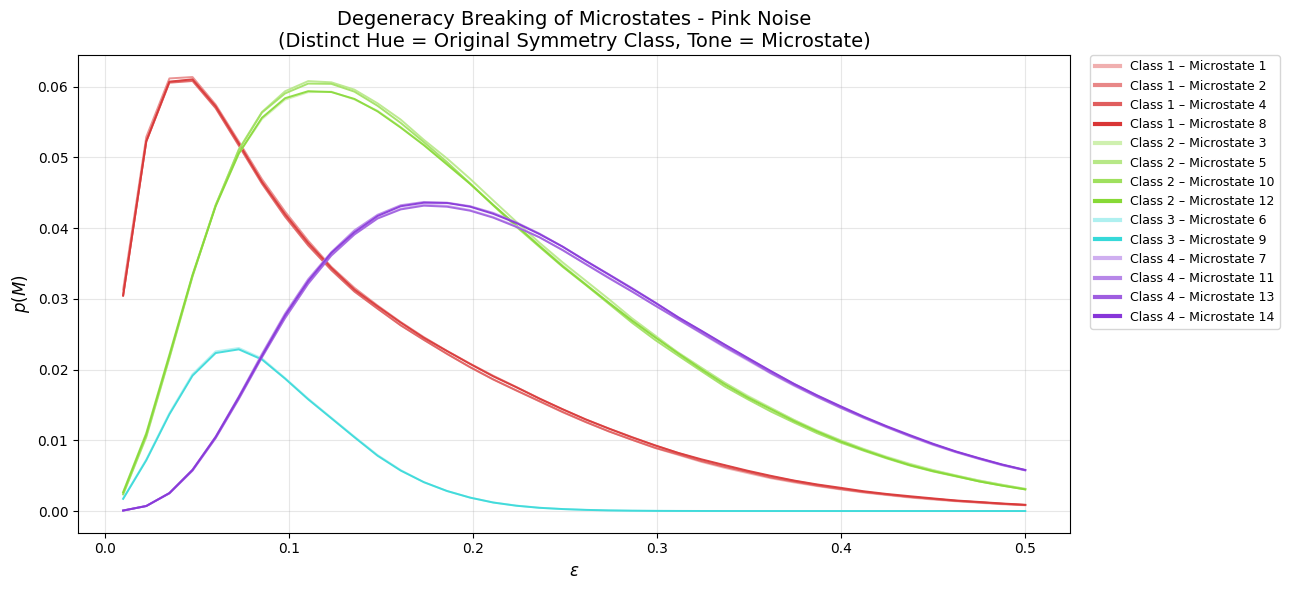

In [ ]:
plot_class_microstate_probabilities(
    'Pink Noise',
    per_eps_pink,
    classes,
    class_ids=[1, 2, 3, 4]
)

In [ ]:
detect_subclasses(per_eps_pink)

[[0], [1, 2, 4, 8], [3, 5, 10, 12], [6, 9], [7, 11, 13, 14], [15]]

## Testing on Brown Noise

### Simulating and Saving Data

In [ ]:
np.random.seed(15)
N = 2000

white = np.random.randn(N)
brown = np.cumsum(white)

X_colored_brown = (brown - np.mean(brown)) / np.std(brown)

In [ ]:
#preparing epsilon sweep
eps_grid = np.linspace(0.01, 0.5, 40)

per_eps_brown = epsilon_sweep_features(
    X_colored_brown,
    eps_grid=eps_grid,
    N_micro=N_micro,
    norm='euclidean',
    normalize=True,
    index_to_class=index_to_class
)

In [ ]:
save_per_eps(per_eps_brown, 'per_eps_brown.pkl')

meta = {
    'N_micro': N_micro,
    'eps_grid': eps_grid,
    'system': 'brown_noise',
    'norm': 'euclidean',
    'normalized': True
}

with open('meta_brown.pkl', 'wb') as f:
    pickle.dump(meta, f)

### Data Loading and Display

In [ ]:
per_eps_brown = load_per_eps('per_eps_brown.pkl')

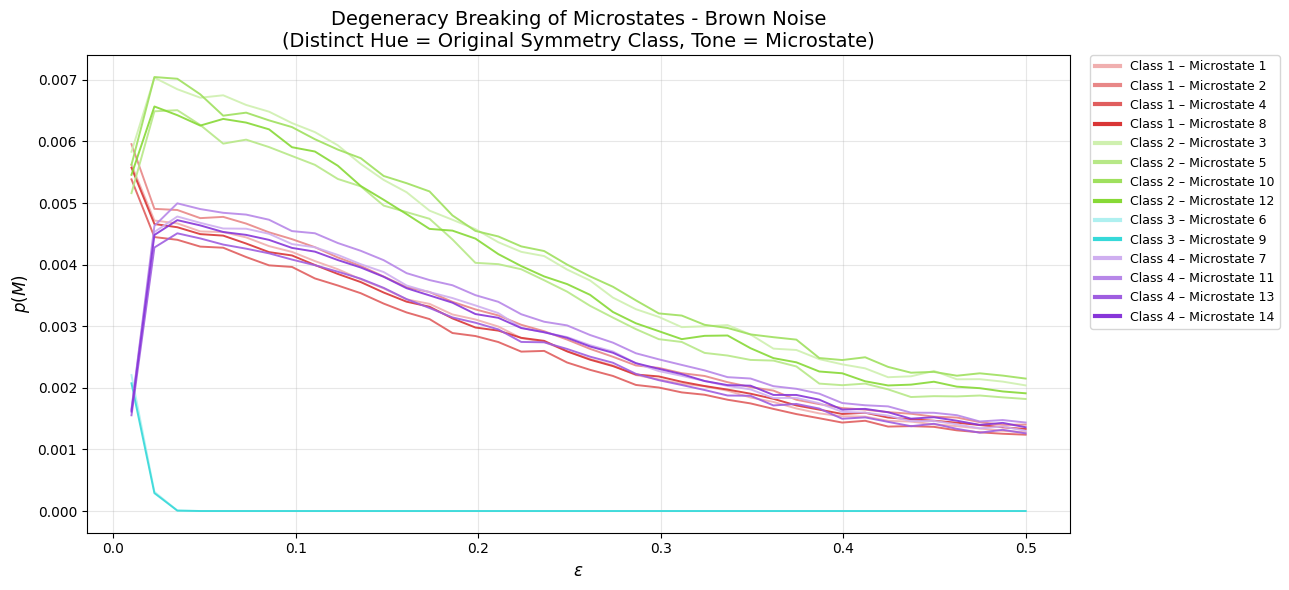

In [ ]:
plot_class_microstate_probabilities(
    'Brown Noise',
    per_eps_brown,
    classes,
    class_ids=[1, 2, 3, 4]
)

In [ ]:
detect_subclasses(per_eps_brown, 15e-4)

[[0], [1, 2, 3, 4, 5, 7, 8, 10, 11, 12, 13, 14], [6, 9], [15]]

## Testing on BETA MAP

### DATA SIMULATION AND SAVING

In [ ]:
def beta_map(x, beta=3.7):
    return (beta * x) % 1.0

beta = 3.7
N = 3000

X = np.zeros(N)
X[0] = 0.213654

for i in range(1, N):
    X[i] = beta_map(X[i-1], beta)

# Descarding transient
X_beta = X[500:]

In [ ]:
per_eps_beta = epsilon_sweep_features(
    X_beta,
    eps_grid=eps_grid,
    N_micro=N_micro,
    norm='euclidean',
    normalize=True,
    index_to_class=index_to_class
)

In [ ]:
save_per_eps(per_eps_beta, 'per_eps_beta.pkl')

meta = {
    'N_micro': N_micro,
    'eps_grid': eps_grid,
    'system': 'beta_map',
    'norm': 'euclidean',
    'normalized': True
}

with open('meta_beta.pkl', 'wb') as f:
    pickle.dump(meta, f)

### DATA LOADING AND DISPLAY

In [ ]:
per_eps_beta = load_per_eps('per_eps_beta.pkl')

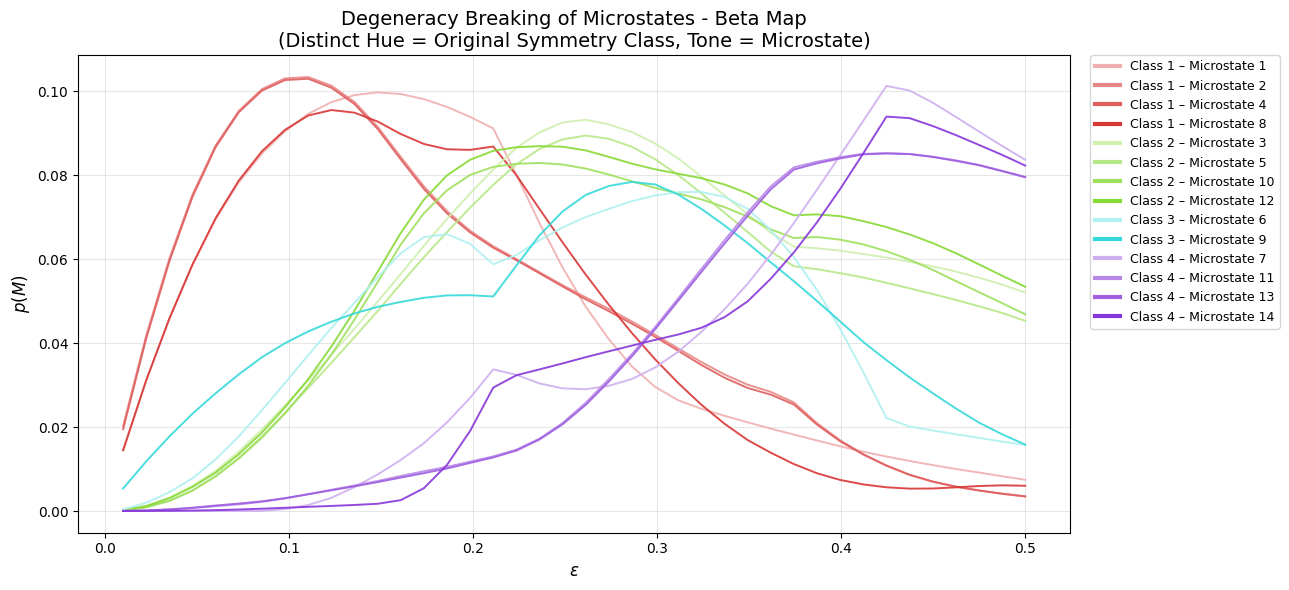

In [ ]:
plot_class_microstate_probabilities(
    'Beta Map',
    per_eps_beta,
    classes,
    class_ids=[1, 2, 3, 4]
)

In [ ]:
subclasses_beta = detect_subclasses(per_eps_beta, 3e-3)
subclasses_beta

[[0],
 [1],
 [2, 4],
 [3],
 [5],
 [6],
 [7],
 [8],
 [9],
 [10],
 [11, 13],
 [12],
 [14],
 [15]]

## Testing on LORENZ SYSTEM


### DATA SIMULATION AND SAVING

In [ ]:
def simulate_lorenz(
    sigma=10.0,
    rho=28.0,
    beta=8/3,
    dt=0.1,
    T_total=200,
    T_transient=20,
    initial_state=(1.5, 1.5, 1.5)
):

    def lorenz(t, state):
        x, y, z = state
        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z
        return [dx, dy, dz]

    t_span = (0, T_total)
    t_eval = np.arange(0, T_total, dt)

    sol = solve_ivp(
        lorenz,
        t_span,
        initial_state,
        t_eval=t_eval,
        method='RK45',
        rtol=1e-9,
        atol=1e-12
    )

    traj = sol.y.T
    transient_cut = int(T_transient / dt)
    traj = traj[transient_cut:]

    traj = (traj - np.mean(traj, axis=0)) / np.std(traj, axis=0)

    return traj

In [ ]:
traj_lorenz = simulate_lorenz()

eps_grid = np.linspace(0.01, 0.5, 40)

per_eps_lorenz = epsilon_sweep_features(
    traj_lorenz,
    eps_grid=eps_grid,
    N_micro=N_micro,
    norm='euclidean',
    normalize=True,
    index_to_class=index_to_class
)

In [ ]:
save_per_eps(per_eps_lorenz, 'per_eps_lorenz.pkl')

meta = {
    'N_micro': N_micro,
    'eps_grid': eps_grid,
    'system': 'lorenz',
    'norm': 'euclidean',
    'normalized': True
}

with open('meta_lorenz.pkl', 'wb') as f:
    pickle.dump(meta, f)

### DATA LOADING AND DISPLAY

In [ ]:
per_eps_lorenz = load_per_eps('per_eps_lorenz.pkl')

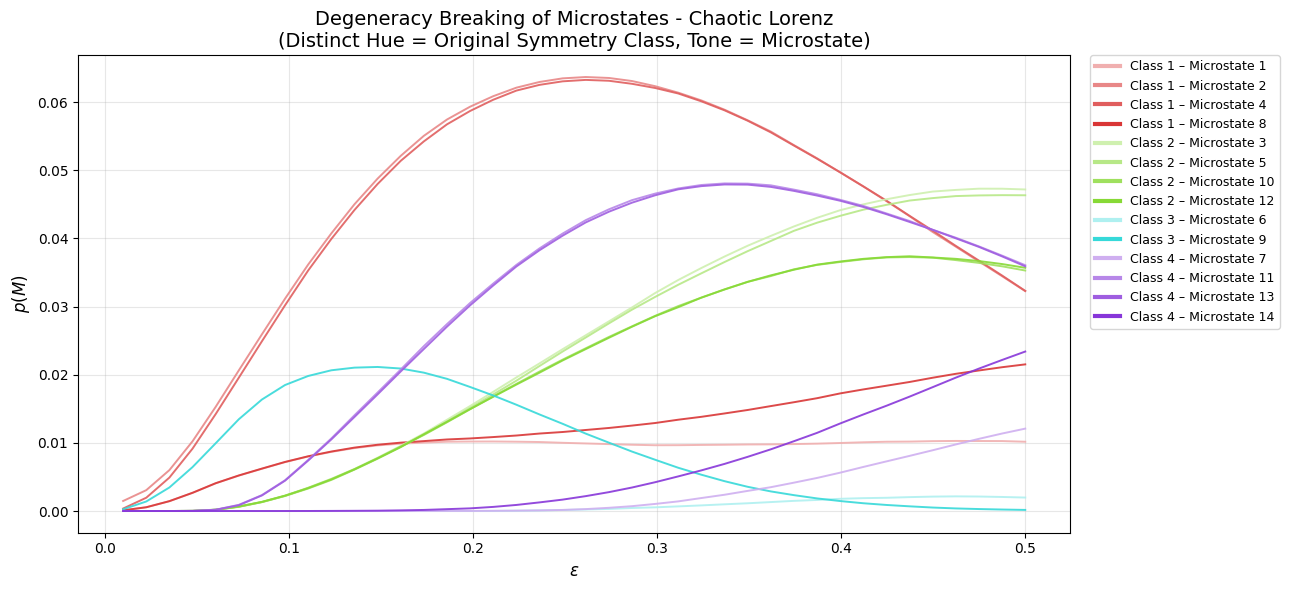

In [ ]:
plot_class_microstate_probabilities(
    'Chaotic Lorenz',
    per_eps_lorenz,
    classes,
    class_ids=[1, 2, 3, 4]
)

In [ ]:
subclasses_lorenz = detect_subclasses(per_eps_lorenz, 1.5e-3)
subclasses_lorenz

[[0], [1], [2, 4], [3, 5], [6], [7], [8], [9], [10, 12], [11, 13], [14], [15]]

## Testing on Logistic Map

### DATA SIMULATION AND SAVING

In [ ]:
def logistic_map(r, x0, n):
    x = np.zeros(n)
    x[0] = x0
    for i in range(1, n):
        x[i] = r * x[i-1] * (1 - x[i-1])
    return x

# Parameters
r = 4.0        # chaotic regime
x0 = 0.213654  # initial condition
n = 2000       # number of iterations

In [ ]:
traj_logistic = logistic_map(r, x0, n)
transient = 200
traj_logistic = traj_logistic[transient:]

eps_grid = np.linspace(0.01, 0.5, 40)

per_eps_logistic = epsilon_sweep_features(
    traj_logistic,
    eps_grid=eps_grid,
    N_micro=N_micro,
    norm='euclidean',
    normalize=True,
    index_to_class=index_to_class
)

In [ ]:
save_per_eps(per_eps_logistic, 'per_eps_logistic.pkl')

meta = {
    'N_micro': N_micro,
    'eps_grid': eps_grid,
    'system': 'logistic',
    'norm': 'euclidean',
    'normalized': True
}

with open('meta_logistic.pkl', 'wb') as f:
    pickle.dump(meta, f)

### DATA LOADING AND DISPLAY

In [ ]:
per_eps_logistic = load_per_eps('per_eps_logistic.pkl')

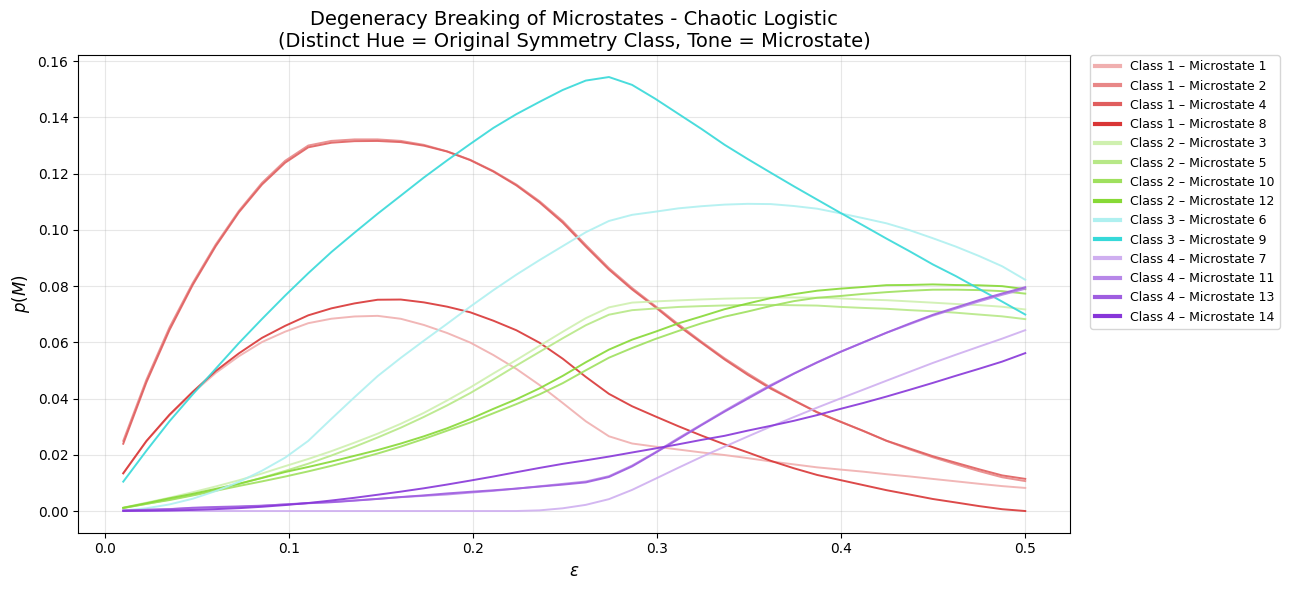

In [ ]:
plot_class_microstate_probabilities(
    'Chaotic Logistic',
    per_eps_logistic,
    classes,
    class_ids=[1, 2, 3, 4]
)

In [ ]:
subclasses_logistic = detect_subclasses(per_eps_logistic, 3e-3)
subclasses_logistic

[[0], [1], [2, 4], [3, 5], [6], [7], [8], [9], [10, 12], [11, 13], [14], [15]]

## Testing on ROSSLER SYSTEM


### DATA SIMULATION AND SAVING

In [ ]:
def simulate_rossler(
    a=0.2,
    b=0.2,
    c=5.7,
    dt=0.1,
    T_total=200,
    T_transient=20,
    initial_state=(1.5, 1.5, 1.5)
):

    def rossler(t, state):
        x, y, z = state
        dx = -y - z
        dy = x + a * y
        dz = b + z * (x - c)
        return [dx, dy, dz]

    t_span = (0, T_total)
    t_eval = np.arange(0, T_total, dt)

    sol = solve_ivp(
        rossler,
        t_span,
        initial_state,
        t_eval=t_eval,
        method='RK45',
        rtol=1e-9,
        atol=1e-12
    )

    traj = sol.y.T
    transient_cut = int(T_transient / dt)
    traj = traj[transient_cut:]

    traj = (traj - np.mean(traj, axis=0)) / np.std(traj, axis=0)

    return traj

In [ ]:
traj_rossler = simulate_rossler()

eps_grid = np.linspace(0.01, 0.5, 40)

per_eps_rossler = epsilon_sweep_features(
    traj_rossler,
    eps_grid=eps_grid,
    N_micro=N_micro,
    norm='euclidean',
    normalize=True,
    index_to_class=index_to_class
)

In [ ]:
save_per_eps(per_eps_rossler, 'per_eps_rossler.pkl')

meta = {
    'N_micro': N_micro,
    'eps_grid': eps_grid,
    'system': 'rossler',
    'norm': 'euclidean',
    'normalized': True
}

with open('meta_rossler.pkl', 'wb') as f:
    pickle.dump(meta, f)

### DATA LOADING AND DISPLAY

In [ ]:
per_eps_rossler = load_per_eps('per_eps_rossler.pkl')

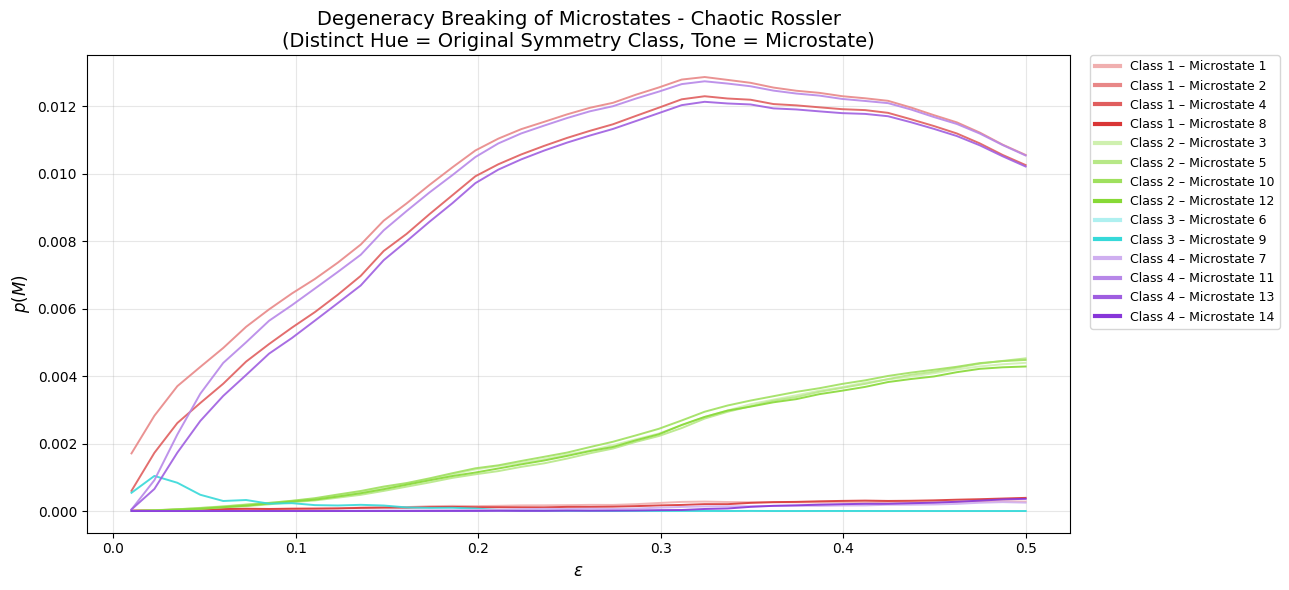

In [ ]:
plot_class_microstate_probabilities(
    'Chaotic Rossler',
    per_eps_rossler,
    classes,
    class_ids=[1, 2, 3, 4]
)

In [ ]:
subclasses_rossler = detect_subclasses(per_eps_rossler[:4], 4.5e-4)
subclasses_rossler

[[0], [1, 3, 5, 6, 7, 8, 10, 12, 14], [2], [4], [9], [11, 13], [15]]

# Correlation Tensor

## Component Consistency Testing

In [ ]:
eps_values = np.linspace(0.01, 0.5, 40)

White Noise

In [ ]:
X_white = np.random.randn(2000)

In [ ]:
max_diff = consistency_test_sweep(
    X_white,
    eps_values,
    recurrence_matrix
)

eps=0.01000  max_diff=0.000e+00
eps=0.02256  max_diff=0.000e+00
eps=0.03513  max_diff=0.000e+00
eps=0.04769  max_diff=0.000e+00
eps=0.06026  max_diff=0.000e+00
eps=0.07282  max_diff=0.000e+00
eps=0.08538  max_diff=0.000e+00
eps=0.09795  max_diff=0.000e+00
eps=0.11051  max_diff=0.000e+00
eps=0.12308  max_diff=0.000e+00
eps=0.13564  max_diff=0.000e+00
eps=0.14821  max_diff=0.000e+00
eps=0.16077  max_diff=0.000e+00
eps=0.17333  max_diff=0.000e+00
eps=0.18590  max_diff=0.000e+00
eps=0.19846  max_diff=0.000e+00
eps=0.21103  max_diff=0.000e+00
eps=0.22359  max_diff=0.000e+00
eps=0.23615  max_diff=0.000e+00
eps=0.24872  max_diff=0.000e+00
eps=0.26128  max_diff=0.000e+00
eps=0.27385  max_diff=0.000e+00
eps=0.28641  max_diff=0.000e+00
eps=0.29897  max_diff=0.000e+00
eps=0.31154  max_diff=0.000e+00
eps=0.32410  max_diff=0.000e+00
eps=0.33667  max_diff=0.000e+00
eps=0.34923  max_diff=0.000e+00
eps=0.36179  max_diff=0.000e+00
eps=0.37436  max_diff=0.000e+00
eps=0.38692  max_diff=0.000e+00
eps=0.39

Beta Map

In [ ]:
max_diff = consistency_test_sweep(
    X_beta,
    eps_values,
    recurrence_matrix
)

eps=0.01000  max_diff=0.000e+00
eps=0.02256  max_diff=0.000e+00
eps=0.03513  max_diff=0.000e+00
eps=0.04769  max_diff=0.000e+00
eps=0.06026  max_diff=0.000e+00
eps=0.07282  max_diff=0.000e+00
eps=0.08538  max_diff=0.000e+00
eps=0.09795  max_diff=0.000e+00
eps=0.11051  max_diff=0.000e+00
eps=0.12308  max_diff=0.000e+00
eps=0.13564  max_diff=0.000e+00
eps=0.14821  max_diff=0.000e+00
eps=0.16077  max_diff=0.000e+00
eps=0.17333  max_diff=0.000e+00
eps=0.18590  max_diff=0.000e+00
eps=0.19846  max_diff=0.000e+00
eps=0.21103  max_diff=0.000e+00
eps=0.22359  max_diff=0.000e+00
eps=0.23615  max_diff=0.000e+00
eps=0.24872  max_diff=0.000e+00
eps=0.26128  max_diff=0.000e+00
eps=0.27385  max_diff=0.000e+00
eps=0.28641  max_diff=0.000e+00
eps=0.29897  max_diff=0.000e+00
eps=0.31154  max_diff=0.000e+00
eps=0.32410  max_diff=0.000e+00
eps=0.33667  max_diff=0.000e+00
eps=0.34923  max_diff=0.000e+00
eps=0.36179  max_diff=0.000e+00
eps=0.37436  max_diff=0.000e+00
eps=0.38692  max_diff=0.000e+00
eps=0.39

Calculating microstate probabilities **via Histogram** VS **via tensor definition**: No practical difference.